# The Artificial Neuron: Code Companion

Optional background: [notes](02_The_Artificial_Neuron_Notes.ipynb). We will calculate one neuron by hand, reproduce it in PyTorch, process a batch, and inspect its decision boundary and limitations.

Run from a fresh kernel in order using the [README setup](README.md). This notebook needs PyTorch, NumPy, and Matplotlib and runs on CPU without downloads. All parameters are deliberately hand-set; **there is no training or evaluation dataset**. These are arithmetic demonstrations, not performance estimates, so a data split would serve no purpose here.

## Start with the problem this lesson solves

Imagine deciding whether a greenhouse needs watering using normalized dryness and warmth readings. Dryness should matter more than warmth, and weak evidence should not automatically trigger watering. A neuron expresses these choices as adjustable weights and a bias.

The inputs are measurements; the weights and bias are stored model parameters. A forward calculation uses the parameters to make a prediction. Learning, introduced later, changes the parameters using examples of correct decisions.

## Follow every contribution through one neuron

Use input $x=[0.8,0.4]$, weights $w=[2,1]$, and bias $b=-1.5$. These are hand-chosen teaching values, not a fitted watering policy.

1. **Weight dryness:** $0.8\times2=1.6$. A change of $0.1$ in dryness changes the score by $0.2$.
2. **Weight warmth:** $0.4\times1=0.4$. A change of $0.1$ in warmth changes the score by $0.1$.
3. **Combine evidence:** $1.6+0.4=2.0$.
4. **Apply the reference level:** $z=2.0-1.5=0.5$. The bias means the weighted evidence must exceed $1.5$ before the score becomes positive.
5. **Convert the score:** a strict step rule gives one because $0.5>0$. Sigmoid instead gives

$$p=\frac{1}{1+e^{-0.5}}=\frac{1}{1+0.606531}\approx0.622459.$$

A threshold of $p>0.5$ makes the same decision as $z>0$. The value $0.622459$ is a model probability only under an appropriate probabilistic interpretation; hand-setting weights does not make it a calibrated 62% real-world chance.

For a less dry greenhouse, $x=[0.2,0.4]$, the same calculation is $z=0.2(2)+0.4(1)-1.5=-0.7$, then $p\approx0.331812$. The parameters have not changed; only the measurements have changed.

**How could this neuron learn?** Suppose the first example's known target is watering, $y=1$. Its binary cross-entropy is $-\ln(0.622459)\approx0.474077$. For this loss with sigmoid, the score gradient is $p-y=-0.377541$. The weight gradients are that number times each input: $[-0.302033,-0.151016]$. The bias gradient is $-0.377541$.

With SGD rate $0.1$, subtract $0.1$ times each gradient:

$$w'\approx[2.030203,1.015102],\qquad b'\approx-1.462246.$$

The updated score is approximately $0.8(2.030203)+0.4(1.015102)-1.462246=0.567957$, and its sigmoid is about $0.6383$. The neuron has moved its response toward the known target. This added one-step explanation is illustrative; the companion's original experiments inspect fixed parameters.

## Why a neuron helps, and where it stops helping

Multiplication controls influence, addition combines evidence, bias controls the reference level, and an activation gives the response its intended form. Learning replaces our hand-picked choices with values supported by training examples. The neuron never understands “dryness” as a word; feature order and numerical meaning come from us.

A single threshold neuron creates one straight boundary in two dimensions. It can combine simple evidence, but cannot represent every decision rule—for example, XOR. Multiple nonlinear units are needed when the useful decision cannot be expressed by one weighted sum.

## Connect the explanation to the code

`x * w` keeps the two contributions separate; `x @ w` adds them. `nn.Linear(2, 1)` stores two weights and one bias and computes the same score. `torch.sigmoid` converts the score, while `(scores > 0)` makes a discrete decision. The hand-set parameters let you inspect the arithmetic before learning is introduced.

The calculations above explain the mechanism before the full experiment. Read the following code cells in order; the printed values and assertions let you compare the implementation with its mathematical meaning.

In [1]:
import platform
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)
plt.rcParams.update({"figure.dpi": 90})
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__, "| NumPy:", np.__version__)
print("Device: CPU | parameters hand-set, no training")

Python: 3.9.6
PyTorch: 2.2.2 | NumPy: 1.26.4
Device: CPU | parameters hand-set, no training


## One input pair, every contribution visible

Dryness is 0.8 and warmth is 0.4. We multiply by weights 2 and 1, then add the bias -1.5 once. `@` computes the dot product of these one-dimensional tensors: multiply matching entries and sum. Sigmoid maps the resulting score to a bounded response; our hand-set result is not a validated probability.

In [2]:
x = torch.tensor([0.8, 0.4], dtype=torch.float32)
w = torch.tensor([2.0, 1.0])
b = torch.tensor(-1.5)
contributions = x * w
z = x @ w + b
step = (z > 0).to(torch.float32)
a = torch.sigmoid(z)
print("Input shape:", tuple(x.shape))
print("Weighted contributions:", contributions.tolist())
print(f"Sum = {contributions.sum().item():.3f}; bias = {b.item():.3f}")
print(f"Score = {z.item():.3f}; step = {step.item():.0f}; sigmoid = {a.item():.3f}")
torch.testing.assert_close(z, torch.tensor(0.5))

Input shape: (2,)
Weighted contributions: [1.600000023841858, 0.4000000059604645]
Sum = 2.000; bias = -1.500
Score = 0.500; step = 1; sigmoid = 0.622


## Reproduce the same computation with `nn.Linear`

`nn.Linear(2, 1)` stores two input weights and one bias. It returns the score, not the activated response. We copy our chosen parameters inside `torch.no_grad()` because these assignments are setup operations, not steps in learning. A single example is passed as one row with shape `(1, 2)`.

In [3]:
neuron = nn.Linear(in_features=2, out_features=1)
with torch.no_grad():
    neuron.weight.copy_(w.reshape(1, 2))
    neuron.bias.copy_(b.reshape(1))
    module_score = neuron(x.reshape(1, 2))
    module_output = torch.sigmoid(module_score)

print("Weight shape:", tuple(neuron.weight.shape), "| bias shape:", tuple(neuron.bias.shape))
print("Output shape:", tuple(module_score.shape))
print(f"PyTorch score: {module_score.item():.3f}; sigmoid: {module_output.item():.3f}")
print("Parameter count:", sum(p.numel() for p in neuron.parameters()))
torch.testing.assert_close(module_score.squeeze(), z)
torch.testing.assert_close(module_output.squeeze(), a)

Weight shape: (1, 2) | bias shape: (1,)
Output shape: (1, 1)
PyTorch score: 0.500; sigmoid: 0.622
Parameter count: 3


## Four examples share the same parameters

The input has shape `(4, 2)`: four rows, two features. PyTorch stores the weight as `(1, 2)`, so we transpose it for matrix multiplication. Adding the `(1,)` bias broadcasts it across all four rows. Each activation below is an alternative way of using the same score—not a sequence of activations applied one after another.

Our step convention returns 0 at a score of exactly zero.

In [4]:
X = torch.tensor([[0.8, 0.4], [0.2, 0.4], [0.5, 0.5], [0.9, 0.9]])
with torch.no_grad():
    scores = neuron(X)
    manual_scores = X @ neuron.weight.T + neuron.bias
    responses = torch.sigmoid(scores)
    relu_responses = torch.relu(scores)
    decisions = (scores > 0).to(torch.int64)

torch.testing.assert_close(scores, manual_scores)
torch.testing.assert_close(scores[:, 0], torch.tensor([0.5, -0.7, 0.0, 1.2]))
print("Batch:", tuple(X.shape), "-> scores:", tuple(scores.shape))
print("dryness  warmth   score   step   ReLU   sigmoid")
for i in range(len(X)):
    print(f"{X[i, 0]:7.1f} {X[i, 1]:7.1f} {scores[i, 0]:7.2f}"
          f" {decisions[i, 0]:6d} {relu_responses[i, 0]:6.2f} {responses[i, 0]:9.3f}")

Batch: (4, 2) -> scores: (4, 1)
dryness  warmth   score   step   ReLU   sigmoid
    0.8     0.4    0.50      1   0.50     0.622
    0.2     0.4   -0.70      0   0.00     0.332
    0.5     0.5    0.00      0   0.00     0.500
    0.9     0.9    1.20      1   1.20     0.769


## Change one thing at a time

We first increase only dryness by 0.1, then only warmth by 0.1. Each score changes by its weight times the input change. Next we add 0.3 to the bias algebraically; every score should rise by the same amount. The stored neuron stays available for the later cells.

In [5]:
with torch.no_grad():
    base = neuron(x.reshape(1, 2)).item()
    for feature, name in enumerate(["dryness", "warmth"]):
        changed = x.clone()
        changed[feature] += 0.1
        new_score = neuron(changed.reshape(1, 2)).item()
        print(f"Increase {name} by 0.1: score change = {new_score - base:.3f}")
    shifted_scores = X @ neuron.weight.T + (neuron.bias + 0.3)
    differences = shifted_scores - scores
print("Increase bias by 0.3: score changes =", np.round(differences.numpy().ravel(), 3))
torch.testing.assert_close(differences, torch.full_like(scores, 0.3))

Increase dryness by 0.1: score change = 0.200
Increase warmth by 0.1: score change = 0.100
Increase bias by 0.3: score changes = [0.3 0.3 0.3 0.3]


## See how bias moves the boundary

Hold the weights fixed at `(2, 1)` and compare three biases. Color indicates sigmoid response; it is not a measured chance of needing water. The black line marks score zero, where sigmoid equals 0.5. On its high-score side the step returns 1. The parameters for these panels are computed separately from the stored neuron.

The parallel lines show that bias shifts the boundary without rotating it. Warmer colors occupy more of the square as bias increases.

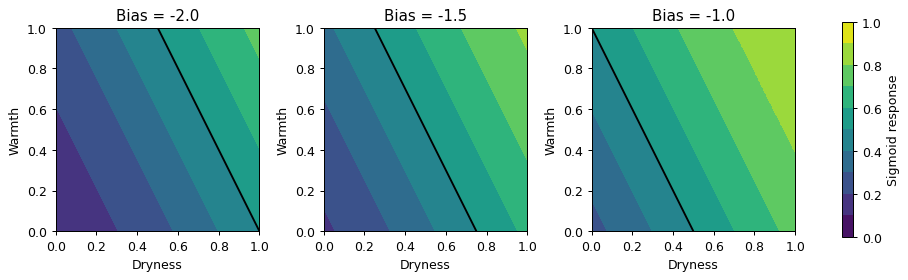

In [6]:
axis = np.linspace(0, 1, 100)
dryness, warmth = np.meshgrid(axis, axis)
fig, axes = plt.subplots(1, 3, figsize=(10, 3.2), constrained_layout=True)
for ax, bias_value in zip(axes, [-2.0, -1.5, -1.0]):
    grid_scores = 2 * dryness + warmth + bias_value
    grid_response = 1 / (1 + np.exp(-grid_scores))
    shading = ax.contourf(dryness, warmth, grid_response,
                          levels=np.linspace(0, 1, 11), cmap="viridis")
    ax.contour(dryness, warmth, grid_scores, levels=[0], colors="black", linewidths=1.5)
    ax.set(title=f"Bias = {bias_value:.1f}", xlabel="Dryness", ylabel="Warmth", aspect="equal")
fig.colorbar(shading, ax=axes, label="Sigmoid response", shrink=0.8)
plt.show()

## Threshold neurons can implement AND and OR

Here inputs are binary switches, rather than sensor readings. Both gates use weights `(1, 1)`. AND uses bias -1.5; OR uses bias -0.5. Putting two rows in the weight matrix lets `nn.Linear(2, 2)` compute two independent neurons together. This groups neurons into a layer: each output column comes from its own neuron. Shape changes from `(4, 2)` inputs to `(4, 2)` scores.

Targets are the complete logic truth table. Checking them verifies a calculation; it is not a held-out accuracy evaluation.

In [7]:
switches = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
gates = nn.Linear(2, 2)
with torch.no_grad():
    gates.weight.copy_(torch.tensor([[1., 1.], [1., 1.]]))
    gates.bias.copy_(torch.tensor([-1.5, -0.5]))
    gate_scores = gates(switches)
    gate_outputs = (gate_scores > 0).to(torch.int64)
expected = torch.tensor([[0, 0], [0, 1], [0, 1], [1, 1]])
assert torch.equal(gate_outputs, expected)
print("x1 x2 | AND OR")
for inputs, outputs in zip(switches.to(torch.int64), gate_outputs):
    print(f" {inputs[0]}  {inputs[1]} |  {outputs[0]}   {outputs[1]}")
print("Weights:", tuple(gates.weight.shape), "| scores:", tuple(gate_scores.shape))

x1 x2 | AND OR
 0  0 |  0   0
 0  1 |  0   1
 1  0 |  0   1
 1  1 |  1   1
Weights: (2, 2) | scores: (4, 2)


## Why XOR needs something more

XOR's positive examples occupy opposite corners. A single failed parameter choice would not prove that no choice can solve it. The notes give the proof: any affine score obeys

$$z(1,1)=z(1,0)+z(0,1)-z(0,0).$$

If the middle two scores are positive and the last score is nonpositive, the left score must be positive. But XOR requires it to be nonpositive. The following cell illustrates the identity with chosen numbers and shows the target geometry. The proof, rather than a search over weights, establishes the limitation.

Example scores for 00, 01, 10, 11: [-0.5, 0.30000001192092896, 0.7000000476837158, 1.5]
z11 = 1.50; z10 + z01 - z00 = 1.50
The example gives a positive score to 11, where XOR requires output 0.


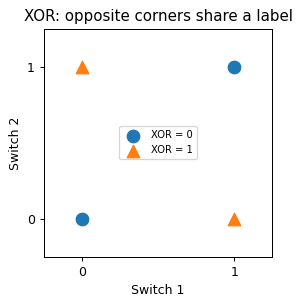

In [8]:
xor_targets = torch.tensor([0, 1, 1, 0])
example_weights = torch.tensor([1.2, 0.8])
example_bias = -0.5
xor_example_scores = switches @ example_weights + example_bias
z00, z01, z10, z11 = xor_example_scores
print("Example scores for 00, 01, 10, 11:", xor_example_scores.tolist())
print(f"z11 = {z11.item():.2f}; z10 + z01 - z00 = {(z10 + z01 - z00).item():.2f}")
torch.testing.assert_close(z11, z10 + z01 - z00)
print("The example gives a positive score to 11, where XOR requires output 0.")

fig, ax = plt.subplots(figsize=(4, 3.5))
for label, marker, color in [(0, "o", "tab:blue"), (1, "^", "tab:orange")]:
    subset = switches[xor_targets == label].numpy()
    ax.scatter(subset[:, 0], subset[:, 1], s=100, marker=marker, color=color, label=f"XOR = {label}")
ax.set(xlabel="Switch 1", ylabel="Switch 2", title="XOR: opposite corners share a label",
       xlim=(-0.25, 1.25), ylim=(-0.25, 1.25), xticks=[0, 1], yticks=[0, 1], aspect="equal")
ax.legend(loc="center", fontsize=8)
plt.tight_layout()
plt.show()

## What to take away

You can now trace a neuron's output back to its individual contributions. `nn.Linear` matches the manual affine calculation, a batch reuses the same parameters for each row, and the activation changes how a score is passed onward. AND and OR work with a single threshold unit each; XOR cannot on these raw inputs. No weights were learned in this notebook.